On Numerical Data

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../../DataBox/titanic_RVI.csv',usecols=['Age','Fare','Survived'])

# % Missing Value
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [3]:
# IO
X = df.drop(columns=['Survived'])
y = df['Survived']

#TTs
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [4]:
# Create a Column to Impute Random value
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

# Pick Random Values From Age Column (Without NA) -> Imputed in place of NA

X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values


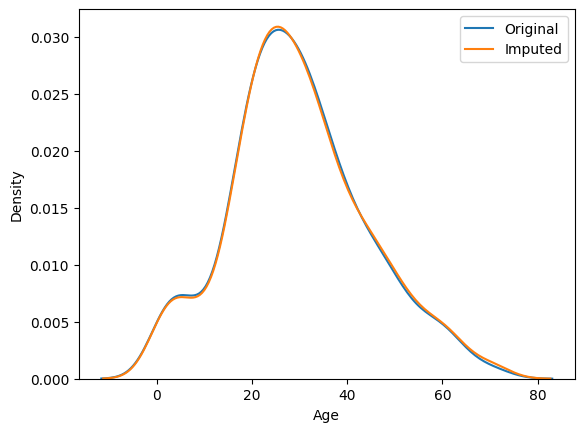

In [5]:
# Modern replacement for sns.distplot(hist=False)
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

# Observation -> Almost Same PDF

Original variable variance:  204.3495133904614
Variance after random imputation:  209.88077944025682
                    Fare         Age  Age_imputed
Fare         2368.246832   71.512440    50.541946
Age            71.512440  204.349513   204.349513
Age_imputed    50.541946  204.349513   209.880779


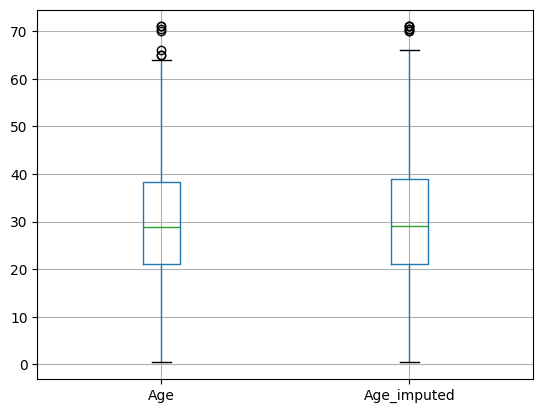

In [6]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

print(X_train[['Fare', 'Age', 'Age_imputed']].cov())

# Slight Change In variance 
# But Change is Co-Variance (Co-Variance Disturbed)

X_train[['Age', 'Age_imputed']].boxplot()

# Slight Impact On Outliars

       # ************************ IMP **************************
# Problem -> When it is deployed in production Environment
# It is Possible that this model generate different output for same input -> AS it select different random number on each iteration

# So it has to be resolved as it should generate same out for same input
# can be fixed by 

# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

def fill_age(row):
    # Check if Age is missing for this specific row
    if pd.isnull(row['Age']):
        # Use Fare as the seed (fallback to 0 if Fare is also NaN)
        seed = int(row['Fare']) if pd.notna(row['Fare']) else 0
        return X_train['Age'].dropna().sample(1, random_state=seed).values[0]
    return row['Age']

# Apply the function to every row
X_train['Age'] = X_train.apply(fill_age, axis=1)

On Categorical Data

In [7]:
data = pd.read_csv('../../../../DataBox/housing_data.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

# null Value Percentage
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [8]:
# IO
X = data
y = data['SalePrice']

# TTS
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Generated New Column -> Easy For Comparision
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [9]:
# Imputation -> Same Logic As before
# for GarageQual
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

# for FireplaceQu
X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [10]:
# Check Frequency of each Category -> Before Imputation and after Imputation
# It should Not Change by huge Factor

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

print(temp)

temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

print(temp)

# Observation ->
# When fewer Data is Missing -> Slight change in frequency
# when Huge Missing data -> Drastic change is Observed -> *** Red Flag *** 
# cannot apply if data missing is huge

    original   imputed
TA  0.951043  0.952055
Fa  0.037171  0.035959
Gd  0.009973  0.010274
Po  0.000907  0.000856
Ex  0.000907  0.000856
    original   imputed
Gd  0.494272  0.655443
TA  0.412439  0.536476
Fa  0.040917  0.049383
Po  0.027823  0.037037
Ex  0.024550  0.032548


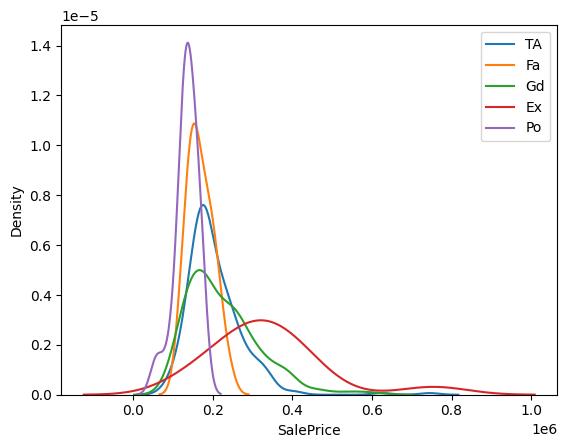

In [11]:
# Visualize the Difference 

for category in X_train['FireplaceQu'].dropna().unique():
    # Filter Data
    subset = X_train[X_train['FireplaceQu'] == category]
    # Kde plot
    sns.kdeplot(subset['SalePrice'], label=category)

plt.legend()
plt.show()

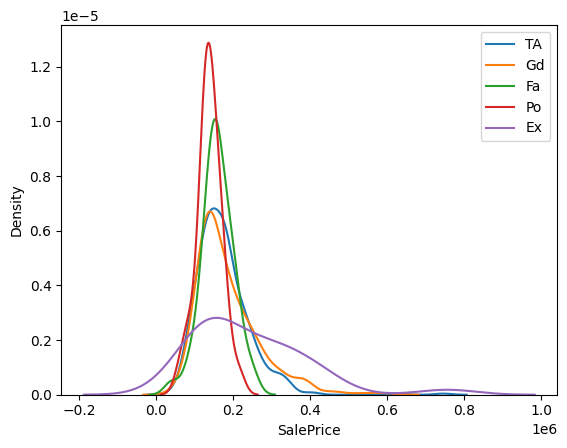

In [12]:
# Visualize the difference

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    # Filter data -> specific category
    subset = X_train[X_train['FireplaceQu_imputed'] == category]
    sns.kdeplot(subset['SalePrice'], label=category)

plt.legend()
plt.show()


# Huge Change in distribution is Observed -> Bad For Linear Models